In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/GSLLevelVol.csv')
df.head()

,Date,S_level_ft,N_level_ft,S_level_m,N_level_m,S_area_m2,N_area_m2,S_vol_m3,N_vol_m3,Total_vol_m3,natlev_m,natlev_ft
0,1847-11-01,4199.864615,4199.864615,1280.118735,1280.118735,2.643110e+09,1.547986e+09,1.194469e+10,6.958589e+09,1.890328e+10,1280.118735,4199.864615
1,1847-12-01,4200.003077,4200.003077,1280.160938,1280.160938,2.668944e+09,1.555834e+09,1.205525e+10,7.023666e+09,1.907892e+10,1280.160938,4200.003077
2,1848-01-01,4200.146154,4200.146154,1280.204548,1280.204548,2.701545e+09,1.559613e+09,1.217513e+10,7.091888e+09,1.926702e+10,1280.204548,4200.146154
3,1848-02-01,4200.289231,4200.289231,1280.248158,1280.248158,2.734145e+09,1.563391e+09,1.229501e+10,7.160110e+09,1.945512e+10,1280.248158,4200.289231
4,1848-03-01,4200.423077,4200.423077,1280.288954,1280.288954,2.764642e+09,1.566926e+09,1.240715e+10,7.223930e+09,1.963108e+10,1280.288954,4200.423077


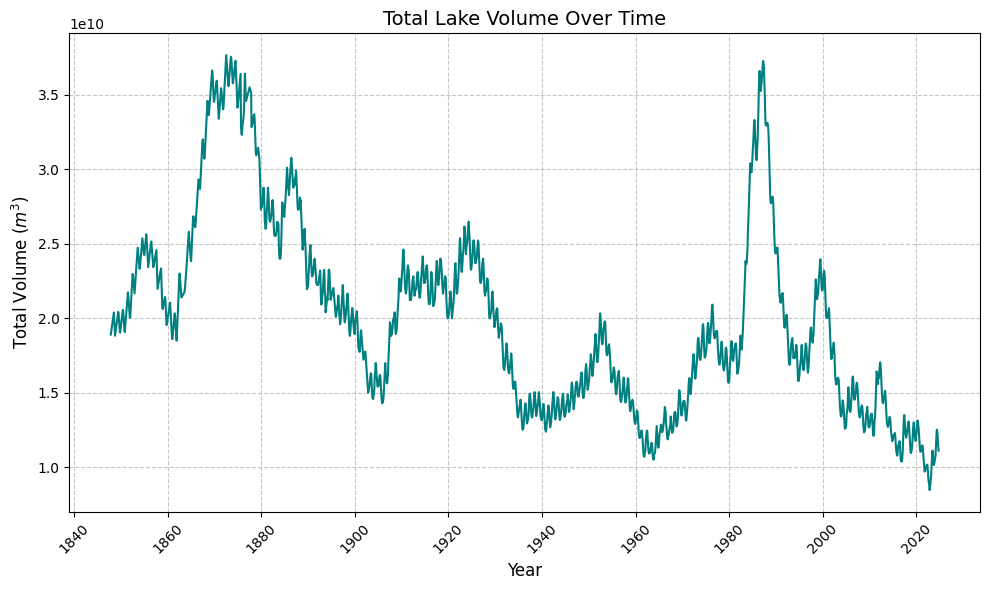

In [3]:
# Convert the 'Date' column from strings to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date to ensure the line plot connects correctly
df = df.sort_values('Date')

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['Total_vol_m3'], linestyle='-', color='teal')

# Formatting the labels
plt.title('Total Lake Volume Over Time', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Volume ($m^3$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## **1. Model Preamble**

### **The Fundamental Framework**
Our primary modeling objective is to track the change in the total volume ($V$) of the Great Salt Lake over time ($t$). The basic system is defined by the following Ordinary Differential Equation (ODE):

$$\frac{dV}{dt} = \text{Inflow} - \text{Outflow}$$

### **Initial Assumptions**
To establish a baseline "naive" model, we have made the following simplifying assumptions
* **System Boundaries:** We assume that the only significant outflow from the lake volume is due to **evaporation**.
* **Geometric Simplification:** We assume the lake bed is shaped like a **hemisphere**. In this geometric configuration, the surface area ($A$) is proportional to the volume ($V$) raised to the two-thirds power:
  $$A \propto V^{2/3}$$
* **Rate of Loss:** The simplest mathematical representation of this outflow is:
  $$\frac{dV}{dt} = -E \cdot A(V)$$

  where $E$ is the evaporation rate (depth lost per unit of time) and $A$ is the surface area of the top of the lake.

### **The Resulting Baseline ODE**
Combining these assumptions, our first model for testing is:
$$\frac{dV}{dt} = -E \cdot V^{2/3}$$

## **Attempt 1: Constant Rate Evaporation Model**

### **1. Hypothesis**
Evaporation occurs at a **constant rate** every single day, independent of seasonal weather patterns, humidity, or temperature fluctuations.

### **2. The Model**
We define the evaporation rate $E$ as a constant $k$:

$E = k$  *(e.g., $k = 90$ mm/month)*

### **3. The ODE (Ordinary Differential Equation)**
To model the change in volume over time, we incorporate a geometric relationship where Surface Area $A$ is proportional to $V^{2/3}$:

$$\frac{dV}{dt} = -k \cdot V^{2/3}$$

### **4. Numerical Simulation Parameters**
* **Solver:** `scipy.integrate.solve_ivp` 
* **Method:** **RK45** (Runge-Kutta)

### **5. Predicted Failure & Limitations**
This model is expected to be **inadequate** for the following reasons:
* **Seasonal Bias:** It does not account for temperature changes throughout the year. 
* **Inaccuracy:** The lake will likely "dry up" too quickly in winter simulations and not fast enough during summer peaks.
* **Purpose:** This serves as our baseline "failed idea" to document the modeling process

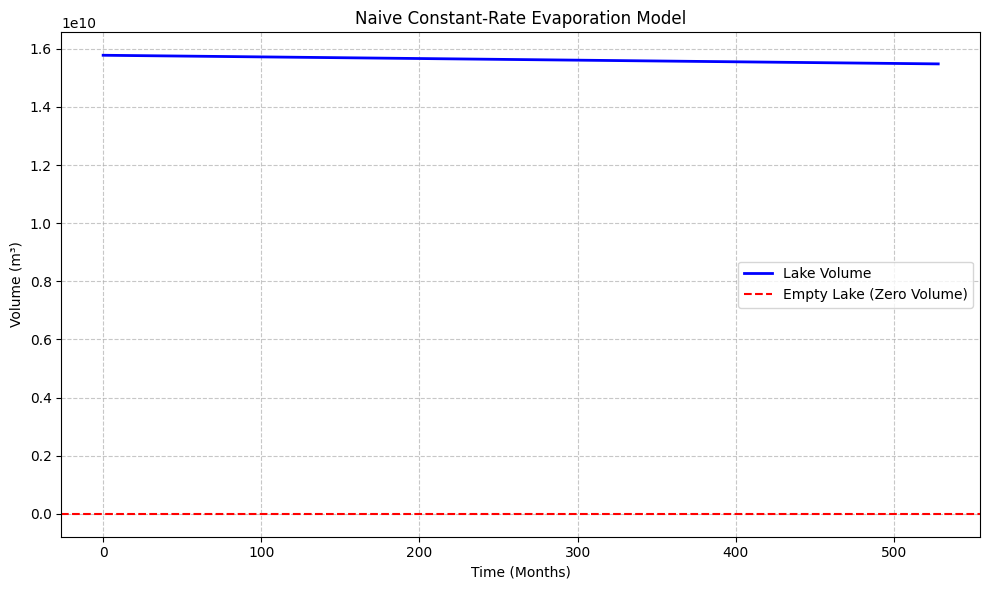

In [8]:
# Define naive constants (using rough estimates for the Great Salt Lake)
# Units: meters (m), cubic meters (m^3), and square meters (m^2)

jan_1980_data = df[(df['Date'].dt.year == 1980) & (df['Date'].dt.month == 1)] # Use total lake volume starting in 1980
INITIAL_VOLUME = jan_1980_data['Total_vol_m3'].values[0] #m^3 
CONSTANT_EVAP_RATE = 0.09  # m per month (equivalent to 90 mm/month)
CONSTANT_AREA = INITIAL_VOLUME ** (2/3) # m^2 A = V^2/3

# Define the ODE function
def naive_evaporation_ode(t, V):
    # The ODE: dV/dt = -E * V^2/3
    current_area = V**(2/3) 
    dVdt = -CONSTANT_EVAP_RATE * current_area
    return dVdt

# Set up simulation parameters
time_span = (0, 44 * 12)  # Simulate for 44 years (in months) 1980 - 2024
t_eval = np.arange(time_span[0], time_span[1] + 1, 1) # Evaluation points for a smooth line
initial_conditions = [INITIAL_VOLUME]

# Run the numerical simulation using scipy
solution = solve_ivp(
    fun=naive_evaporation_ode,
    t_span=time_span,
    y0=initial_conditions,
    t_eval=t_eval,
    method='RK45' # Standard Runge-Kutta numerical solver
)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label='Lake Volume', color='blue', linewidth=2)
plt.axhline(0, color='red', linestyle='--', label='Empty Lake (Zero Volume)')

plt.title('Naive Constant-Rate Evaporation Model')
plt.xlabel('Time (Months)')
plt.ylabel('Volume (m³)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Attempt 2: Mass Transfer (Dalton's Law) Model with Simulated Weather**

### **1. Hypothesis**
Evaporation is not constant; it is dynamically driven by wind sweeping moisture away and the air's vapor pressure deficit. By incorporating seasonal variations in temperature and wind, we can model a more realistic, fluctuating evaporation rate.

### **2. The Model**
We define the evaporation rate $E$ using Dalton's Law, where evaporation is a function of wind speed $u$, saturation vapor pressure $e_s$, and actual vapor pressure $e_a$:
> $E = f(u) \cdot (e_s - e_a)$

To test this mechanism, we simulate temperature and wind speed as time-dependent sine waves to mimic seasonal weather patterns.

### **3. The ODE (Ordinary Differential Equation)**
We use an ODE to model the volume change. We maintain the geometric assumption for Surface Area ($A \propto V^{2/3}$) and substitute our dynamic evaporation rate:

$$\frac{dV}{dt} = -[f(u(t)) \cdot (e_s(t) - e_a(t))] \cdot V^{2/3}$$

### **4. Numerical Simulation Parameters**
* **Solver:** `scipy.integrate.solve_ivp`
* **Method:** **RK45** Runge-Kutta

### **5. Predicted Failure & Limitations**
While mechanically superior to the constant-rate model, this version will ultimately be inappropriate for final data comparison:
* **Synthetic Data Bias:** The model relies on perfectly smooth, simulated sine waves for weather, which ignores real-world meteorological anomalies, storms, and actual historical climate patterns.
* **Purpose:** This iteration successfully proves that our ODE framework can dynamically respond to time-dependent variables.

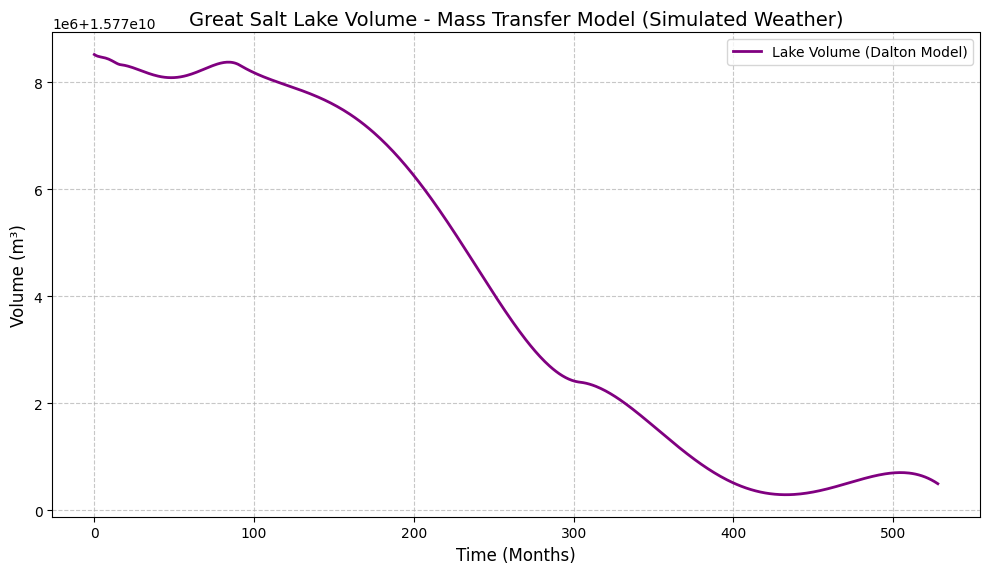

In [7]:
# Constants & Initial Conditions
jan_1980_data = df[(df['Date'].dt.year == 1980) & (df['Date'].dt.month == 1)] # Use total lake volume starting in 1980
INITIAL_VOLUME = jan_1980_data['Total_vol_m3'].values[0] #m^3
RELATIVE_HUMIDITY = 0.40 # 40% average humidity
WIND_COEFF_A = 0.001     # Empirical mass transfer coefficient
WIND_COEFF_B = 0.0005    # Empirical mass transfer coefficient

# Weather Functions (Simulating Seasons)
def simulate_temperature(t):
    # Simulates temperature in Celsius over a 12 month year
    # Peaks in summer (around month 7), lowest in winter
    mean_temp = 11.0
    amplitude = 15.0
    return mean_temp + amplitude * np.sin(2 * np.pi * (t - 7) / 12)

def simulate_wind_speed(t):
    # Simulates wind speed in m/s
    mean_wind = 3.0
    amplitude = 1.5
    return mean_wind + amplitude * np.sin(2 * np.pi * t / 6)

def calculate_vapor_pressures(T, RH):
    # Magnus-Tetens formula for saturation vapor pressure (kPa)
    es = 0.611 * np.exp((17.27 * T) / (T + 237.3))
    # Actual vapor pressure
    ea = es * RH
    return es, ea

# ODE Function
def daltons_evaporation_ode(t, V):
    # Get current weather for day month t
    T = simulate_temperature(t)
    u = simulate_wind_speed(t)

    # Calculate vapor pressures
    es, ea = calculate_vapor_pressures(T, RELATIVE_HUMIDITY)

    # Calculate Dalton's Evaporation Rate (E)
    # E = f(wind) * (es - ea)
    wind_function = WIND_COEFF_A + WIND_COEFF_B * u
    E = wind_function * (es - ea)

    # Ensure evaporation doesn't go negative
    E = max(E, 0)

    # Calculate Area
    current_area = V**(2/3)

    # The Final Differential
    dVdt = -E * current_area
    return dVdt

# Run Simulation
time_span = (0, 44 * 12)  # Simulate for 44 years (in months) 1980 - 2024
t_eval = np.arange(time_span[0], time_span[1] + 1, 1) # Evaluation points for a smooth line

solution = solve_ivp(
    fun=daltons_evaporation_ode,
    t_span=time_span,
    y0=[INITIAL_VOLUME],
    t_eval=t_eval,
    method='RK45'
)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label='Lake Volume (Dalton Model)', color='purple', linewidth=2)

plt.title("Great Salt Lake Volume - Mass Transfer Model (Simulated Weather)", fontsize=14)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Volume (m³)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()